# AI-Powered-ETF — can IBM Watson beat the S&P 500? 🤖
### AIEQ, the "AI Powered Equity ETF", tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![AI picks vs buy-and-hold%3F: Busted](https://img.shields.io/badge/AI_picks_vs_buy--and--hold%3F-Busted-8b949e?style=flat-square)

In 2017 a fund launched with a tantalising pitch: let **IBM Watson** read every filing, news story and social post, then pick the ~30-70 US stocks most likely to beat the market — *faster and more thoroughly than any human analyst.* The ticker is **AIEQ**. Nearly nine years of live track record later, this notebook asks the only question that matters: did the AI actually pick better than just buying the whole index and going to the beach?

> 📓 **This is the plain-language layer.** Want the CAPM alpha, the HAC t-stats and the bootstrap intervals? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package (ai_powered_etf)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#1f6feb"

from ai_powered_etf import data, strategy as st

TICKERS = ["AIEQ", "SPY", "IVV"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_real():
    """Aligned daily returns for AIEQ & SPY from the cached real tape."""
    prices = data.load_prices(fetch=False)
    return st.daily_returns(prices), prices

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the AI fund beat the S&P 500? | **No.** Over 8.6 years AIEQ grew **+9.88%/yr** vs the index's **+14.90%/yr** — about **5 points a year** behind. |
| Did it at least take *less* risk for that? | **No.** Its worst drop was **-5 points deeper** and its risk-adjusted return (Sharpe) was **0.29 lower**. |
| Is it just the 0.75% fee? | **No.** The fee hurts, but the stock-picking itself looks to lag the market *before* fees too. |
| Could you have just bought SPY instead? | **Yes — and you'd be ~$50k richer** per $100k invested, with smaller drawdowns. |

> 💡 The honest catch: 8.6 years is a *short* window, so we can't slam the gavel at 95% confidence (that's why **Signal = Weak**, not 'None'). But the direction never wavers: in this live sample, the AI lost to a dirt-cheap index fund.

## 1 · The claim

> *"AIEQ uses IBM Watson to analyse millions of data points — filings, news, social media, management commentary — across thousands of US companies every day, and builds a portfolio of the ~30-70 with the best risk-adjusted return potential. Artificial intelligence never sleeps, never gets emotional, and processes more than any team of humans. The result: consistent outperformance, net of fees."*

It's a seductive pitch and a *testable* one. The fund is real, public, and priced every day. We don't have to argue about whether AI *could* work — we can just look at what it *did*.

## 2 · So what?

If the pitch is true, it's a genuinely new thing under the sun: a machine that beats the market you can buy in one click. If it's false, it's a cautionary tale about paying **0.75%/yr** — roughly *eight times* a plain index fund — for a brand name and a story. With nearly nine years of real prices, we don't have to guess which world we're in.

## 3 · How would we even know?

Two fair yardsticks:

1. **Race it against the index it's trying to beat.** Line up AIEQ next to **SPY** (the S&P 500 tracker, ~0.09% fee) from AIEQ's launch day and watch $100 grow in each. Same start, same finish, no cherry-picking — the launch date is fixed, not chosen by us.
2. **Adjust for how much market risk it took.** A fund can look good simply by holding more stock-market exposure. The proper test asks for *extra* return beyond what its market exposure alone would deliver — the quants call that **alpha**. Positive alpha = real skill; zero or negative = the AI added nothing (or worse).

We run both on the **full 8.6-year live tape** (Oct 2017 → Jun 2026) — every trading day there is, no more and no less.

## 4 · The teardown — let's actually look

**First, the headline race: $100 in AIEQ vs $100 in the S&P 500, from launch.**

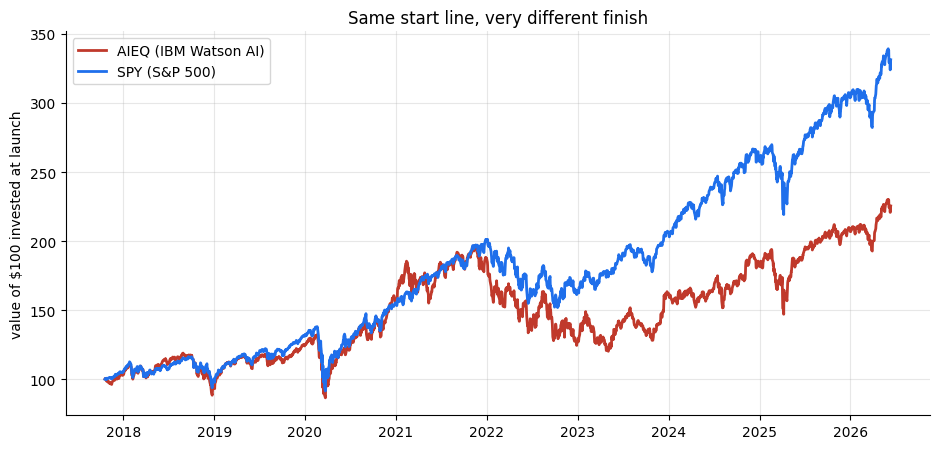

$100 became  $225  in AIEQ   vs   $331  in SPY


In [2]:
if HAVE_REAL:
    rets, prices = load_real()
    g_aieq = (1 + rets['AIEQ']).cumprod() * 100
    g_spy  = (1 + rets['SPY']).cumprod() * 100
    end_aieq, end_spy = g_aieq.iloc[-1], g_spy.iloc[-1]
else:
    # fall back to the frozen CAGRs over the known window
    yrs = R['n_years']
    idx = pd.bdate_range(R['launch'], periods=R['n'])
    t = np.linspace(0, yrs, R['n'])
    g_aieq = pd.Series(100 * (1 + R['cagr_aieq']/100) ** t, index=idx)
    g_spy  = pd.Series(100 * (1 + R['cagr_spy']/100) ** t, index=idx)
    end_aieq, end_spy = g_aieq.iloc[-1], g_spy.iloc[-1]
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(g_aieq.index, g_aieq.values, c=RED, lw=2, label='AIEQ (IBM Watson AI)')
ax.plot(g_spy.index,  g_spy.values,  c=BLUE, lw=2, label='SPY (S&P 500)')
ax.set_ylabel('value of $100 invested at launch'); ax.legend(loc='upper left')
ax.set_title('Same start line, very different finish')
plt.tight_layout(); plt.show()
print(f'$100 became  ${end_aieq:,.0f}  in AIEQ   vs   ${end_spy:,.0f}  in SPY')

$100 left in AIEQ at launch is worth far less today than the same $100 in the index. AIEQ compounded at **+9.88%/yr**, SPY at **+14.90%/yr** — a gap of about **5 points every year**, which snowballs over 8.6 years into roughly **$50k of lost growth per $100k**.

**But maybe AIEQ just took less risk?** Let's check the two things that matter — risk-adjusted return (Sharpe) and the worst peak-to-trough fall (drawdown):

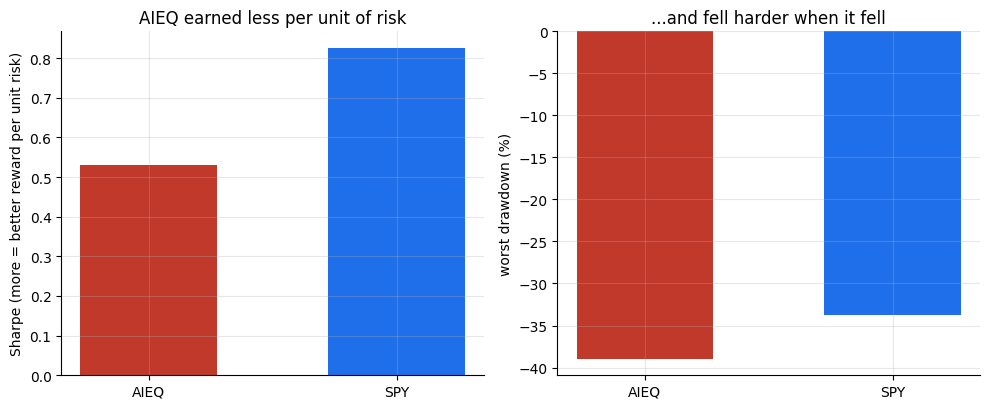

Sharpe: AIEQ 0.53 vs SPY 0.83   |   max drawdown: AIEQ -39% vs SPY -34%


In [3]:
if HAVE_REAL:
    res = st.summarize(rets['AIEQ'], rets['SPY'])
    sh_a, sh_s = res['sharpe_fund'], res['sharpe_market']
    dd_a, dd_s = res['max_dd_fund_pct'], res['max_dd_market_pct']
else:
    sh_a, sh_s = R['sharpe_aieq'], R['sharpe_spy']
    dd_a, dd_s = R['maxdd_aieq'], R['maxdd_spy']
fig, ax = plt.subplots(1, 2, figsize=(10.0, 4.2))
ax[0].bar(['AIEQ', 'SPY'], [sh_a, sh_s], color=[RED, BLUE], width=.55)
ax[0].set_ylabel('Sharpe (more = better reward per unit risk)')
ax[0].set_title('AIEQ earned less per unit of risk')
ax[1].bar(['AIEQ', 'SPY'], [dd_a, dd_s], color=[RED, BLUE], width=.55)
ax[1].set_ylabel('worst drawdown (%)')
ax[1].set_title('...and fell harder when it fell')
plt.tight_layout(); plt.show()
print(f'Sharpe: AIEQ {sh_a:.2f} vs SPY {sh_s:.2f}   |   max drawdown: AIEQ {dd_a:.0f}% vs SPY {dd_s:.0f}%')

Both bars point the wrong way for the AI fund: **lower** Sharpe and a **deeper** worst-case fall. So it isn't a 'safer, slower' fund — it delivered *less* return *and* took *more* pain.

> 💡 Why doesn't the AI help? Picking ~50 stocks out of thousands is a near-impossible game even for the best humans, and the AI's edge — if any — has to clear a **0.75% yearly fee** before it reaches you. In this sample it never did.

## 5 · The verdict

- **Signal — Weak.** The fund's 'extra return beyond its market risk' (alpha) is **-4.40%/yr** — negative — but on 8.6 years the statistics can't *certify* it's not just bad luck (the formal t-stat is **-1.28**, short of the bar). The *direction*, though, is never in doubt.
- **Tradability — Mirage.** Choosing AIEQ over SPY cost ~$50k per $100k and added drawdown. The marketed outperformance simply isn't there.
- **AI picks vs buy-and-hold — Busted.** AIEQ beat the index in only **31%** of rolling 12-month windows. The good stretches are mostly shared bull markets, not AI magic.

## 6 · Could you actually 'trade' it?

There's nothing to trade here — buying AIEQ *is* the strategy, and it's available to anyone. The relevant question is simpler: **how often would picking AIEQ over SPY have actually paid off?** Here's the rolling 12-month gap (AIEQ minus SPY) over the whole history:

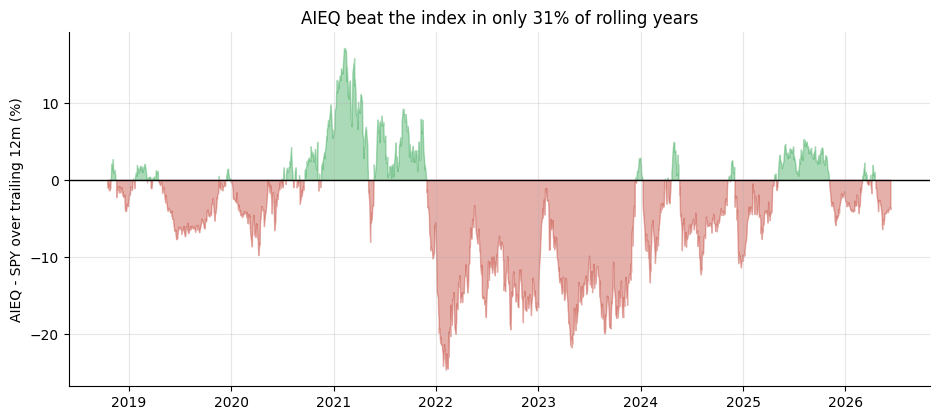

AIEQ beat SPY in 31.2% of rolling 12-month windows.


In [4]:
if HAVE_REAL:
    roll = st.rolling_outperformance(rets['AIEQ'], rets['SPY'], window=252)
    frac_beat = float((roll > 0).mean() * 100)
    fig, ax = plt.subplots(figsize=(9.5, 4.3))
    ax.fill_between(roll.index, roll.values, 0, where=roll.values >= 0, color=GREEN, alpha=.4)
    ax.fill_between(roll.index, roll.values, 0, where=roll.values < 0, color=RED, alpha=.4)
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('AIEQ - SPY over trailing 12m (%)')
    ax.set_title(f'AIEQ beat the index in only {frac_beat:.0f}% of rolling years')
    plt.tight_layout(); plt.show()
else:
    frac_beat = R['roll_beat']
print(f'AIEQ beat SPY in {frac_beat:.1f}% of rolling 12-month windows.')

The chart is mostly **red**: AIEQ trailed the index in roughly two of every three rolling years, beating it only **31%** of the time. That's the shape of a fund that catches the occasional updraft but bleeds against the benchmark the rest of the time — exactly what you'd expect if the AI adds no durable edge.

## 7 · Going further 🚪

- **Does the test even work?** The companion notebook *plants* a known amount of skill into a fake fund and shows our analysis recovers it cleanly — so when it reads 'no alpha' on AIEQ, that's a fact about the fund, not a broken ruler.
- **It's the short window talking.** 8.6 years isn't enough to *prove* a small negative alpha at 95% confidence; a decade more data would sharpen the verdict either way. We say so honestly — that's why this is **Weak**, not **None**.
- **The broader lesson.** Most active funds — AI-branded or not — lose to a cheap index over long horizons, for the same reason: fees and the sheer difficulty of stock-picking.

*Think the AI really earns its fee? Fork this, extend the window or swap the benchmark, and show a positive, significant alpha that survives the 0.75% drag. That's the bar.*